````{margin}
```{attributiongrey} Attribution
:class: attribution

This page is adapted from https://github.com/twrijsdijk/Examples-for-the-use-of-springs-in-SymPy/blob/main/VB_veerinbalk_midden_oplegging.py

```
```` 


# Voorbeeld veer in balk midden oplegging

In [ ]:
%pip install git+https://github.com/twrijsdijk/sympy

belasting -100*SingularityFunction(x, 0, -1)/39 - 100*SingularityFunction(x, 2, -1) - 4500*SingularityFunction(x, 3, -4)/13 + 6700*SingularityFunction(x, 3, -1)/39 - 100*SingularityFunction(x, 5, -1) + 400*SingularityFunction(x, 6, -1)/13
Dwarskrachten 100*SingularityFunction(x, 0, 0)/39 + 100*SingularityFunction(x, 2, 0) + 4500*SingularityFunction(x, 3, -3)/13 - 6700*SingularityFunction(x, 3, 0)/39 + 100*SingularityFunction(x, 5, 0) - 400*SingularityFunction(x, 6, 0)/13
Reactiekrachten {R_0: -100/39, R_6: 400/13, R_3: 6700/39}
Moment 100*SingularityFunction(x, 0, 1)/39 + 100*SingularityFunction(x, 2, 1) + 4500*SingularityFunction(x, 3, -2)/13 - 6700*SingularityFunction(x, 3, 1)/39 + 100*SingularityFunction(x, 5, 1) - 400*SingularityFunction(x, 6, 1)/13
Hoeverdraaiing -SingularityFunction(x, 0, 2)/3900 - SingularityFunction(x, 2, 2)/100 - 9*SingularityFunction(x, 3, -1)/130 + 67*SingularityFunction(x, 3, 2)/3900 - SingularityFunction(x, 5, 2)/100 + SingularityFunction(x, 6, 2)/325 + 73

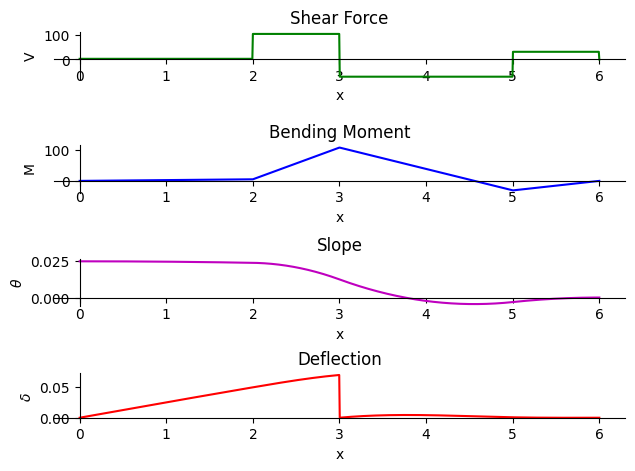

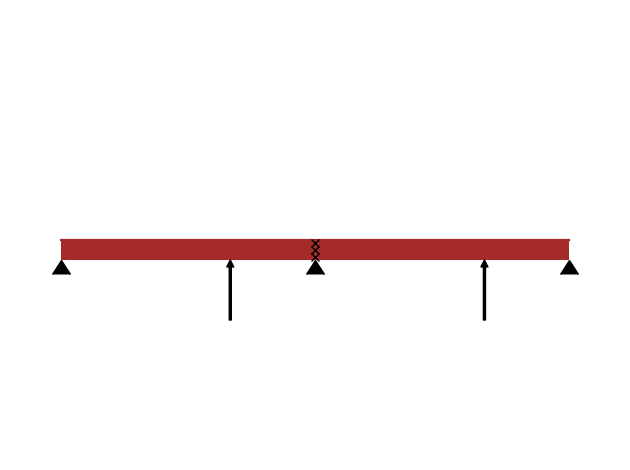

In [1]:
from sympy.physics.continuum_mechanics import Beam
from sympy import symbols

#Omschrijving van de balk
b = Beam(6, 500, 10)
r0 = b.apply_support(0,'pin')
r3 = b.apply_support(3,'pin')
r6 = b.apply_support(6,'pin')
b.apply_load(-100, 5, -1)
b.apply_load(-100, 2, -1)
b.apply_spring(3, 1000)

#berekeningen
b.solve_for_reaction_loads(r0, r3, r6)
print('belasting', b.load)
print('Dwarskrachten', b.shear_force())
print('Reactiekrachten', b.reaction_loads)
print('Moment',b.bending_moment())
print('Hoeverdraaiing',b.slope())
print('Doorbuiging',b.deflection())

#plots
axes = b.plot_loading_results()
d = b.draw()
d.show()